# Health Access Spatial Clusters

Explore spatial clustering in a neighborhood health-access proxy and summarize high-priority clusters.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by health geography examples in spatial analysis teaching notebooks.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import libpysal
import esda
import spreg
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
zones = gpd.read_file(DATA / 'zones.geojson')
zones['income_proxy'] = 25 + zones['population'] / 900 + zones['green_ratio'] * 30
zones['target_rate'] = zones['score'] + zones['income_proxy'] * 0.35
print({'zones': len(zones), 'crs': str(zones.crs)})
display(zones[['zone_id', 'population', 'green_ratio', 'target_rate']].head())


{'zones': 36, 'crs': 'EPSG:4326'}


,zone_id,population,green_ratio,target_rate
0,Z0000,4233,0.115240,58.338190
1,Z0001,7063,0.127997,64.179855
2,Z0002,9645,0.161759,58.606268
3,Z0003,5918,0.147116,48.262940
4,Z0004,7767,0.127552,41.897609


In [2]:
w = libpysal.weights.Queen.from_dataframe(zones, ids=zones['zone_id'].tolist(), use_index=False)
w.transform = 'r'
moran = esda.Moran(zones['target_rate'].to_numpy(), w)
print(f"Moran's I: {moran.I:.3f}")
print(f'p-value (permutation): {moran.p_sim:.4f}')
lag = libpysal.weights.spatial_lag.lag_spatial(w, zones['target_rate'])
zones['spatial_lag'] = lag


('WARNING: ', 'Z0000', ' is an island (no neighbors)')
('WARNING: ', 'Z0001', ' is an island (no neighbors)')
('WARNING: ', 'Z0002', ' is an island (no neighbors)')
('WARNING: ', 'Z0003', ' is an island (no neighbors)')
('WARNING: ', 'Z0004', ' is an island (no neighbors)')
('WARNING: ', 'Z0005', ' is an island (no neighbors)')
('WARNING: ', 'Z0100', ' is an island (no neighbors)')
('WARNING: ', 'Z0101', ' is an island (no neighbors)')
('WARNING: ', 'Z0102', ' is an island (no neighbors)')
('WARNING: ', 'Z0103', ' is an island (no neighbors)')
('WARNING: ', 'Z0104', ' is an island (no neighbors)')
('WARNING: ', 'Z0105', ' is an island (no neighbors)')
('WARNING: ', 'Z0200', ' is an island (no neighbors)')
('WARNING: ', 'Z0201', ' is an island (no neighbors)')
('WARNING: ', 'Z0202', ' is an island (no neighbors)')
('WARNING: ', 'Z0203', ' is an island (no neighbors)')
('WARNING: ', 'Z0204', ' is an island (no neighbors)')
('WARNING: ', 'Z0205', ' is an island (no neighbors)')
('WARNING:

/opt/conda/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 36 disconnected components.
 There are 36 islands with ids: Z0000, Z0001, Z0002, Z0003, Z0004, Z0005, Z0100, Z0101, Z0102, Z0103, Z0104, Z0105, Z0200, Z0201, Z0202, Z0203, Z0204, Z0205, Z0300, Z0301, Z0302, Z0303, Z0304, Z0305, Z0400, Z0401, Z0402, Z0403, Z0404, Z0405, Z0500, Z0501, Z0502, Z0503, Z0504, Z0505.
  W.__init__(self, neighbors, ids=ids, **kw)
/opt/conda/lib/python3.13/site-packages/esda/moran.py:252: RuntimeWarning: invalid value encountered in scalar divide
  self.VI_norm = v_num / v_den - (1.0 / (n - 1)) ** 2
/opt/conda/lib/python3.13/site-packages/esda/moran.py:264: RuntimeWarning: invalid value encountered in scalar divide
  VIR = (A - B) / ((n - 1) * (n - 2) * (n - 3) * s02) - EI * EI
/opt/conda/lib/python3.13/site-packages/esda/moran.py:272: RuntimeWarning: divide by zero encountered in scalar divide
  return self.n / s0 * inu

In [3]:
y = zones[['target_rate']].to_numpy()
x = zones[['population', 'green_ratio']].to_numpy()
ols = spreg.OLS(y, x, name_y='target_rate', name_x=['population', 'green_ratio'])
print(ols.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  : target_rate                Number of Observations:          36
Mean dependent var  :     62.9941                Number of Variables   :           3
S.D. dependent var  :     10.1003                Degrees of Freedom    :          33
R-squared           :      0.0666
Adjusted R-squared  :      0.0101
Sum squared residual:      3332.6                F-statistic           :      1.1780
Sigma-square        :     100.988                Prob(F-statistic)     :      0.3205
S.E. of regression  :      10.049                Log likelihood        :    -132.586
Sigma-square ML     :      92.572                Akaike info criterion :     271.171
S.E of regression ML:      9.6214                Schwarz criterion     :     275.922

-----------------

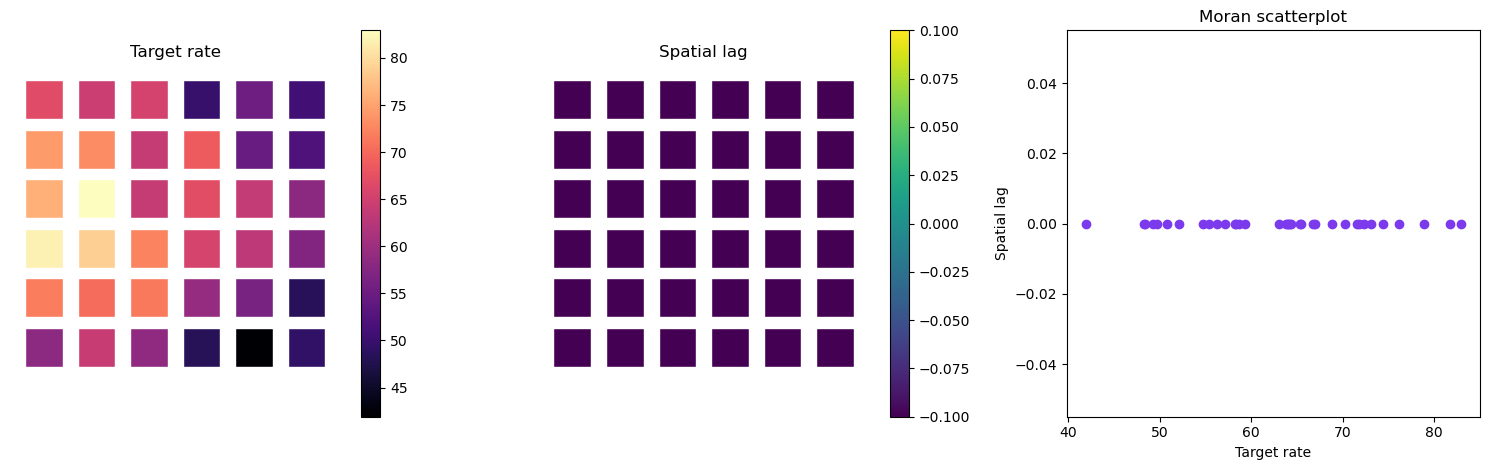

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
zones.plot(column='target_rate', cmap='magma', legend=True, ax=axes[0], edgecolor='white')
axes[0].set_title('Target rate')
zones.plot(column='spatial_lag', cmap='viridis', legend=True, ax=axes[1], edgecolor='white')
axes[1].set_title('Spatial lag')
axes[2].scatter(zones['target_rate'], zones['spatial_lag'], color='#7c3aed')
axes[2].set_xlabel('Target rate')
axes[2].set_ylabel('Spatial lag')
axes[2].set_title('Moran scatterplot')
for ax in axes[:2]:
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUT / 'spatial_statistics.png', dpi=160)
plt.show()


In [5]:
high = zones.sort_values('target_rate', ascending=False).head(5)[['zone_id', 'target_rate', 'spatial_lag']]
display(high)


,zone_id,target_rate,spatial_lag
19,Z0301,82.936938,0.0
12,Z0200,81.719444,0.0
13,Z0201,78.906795,0.0
18,Z0300,76.129798,0.0
24,Z0400,74.414468,0.0
